# Analyse des simulations 2D

Ce notebook permet de traiter automatiquement les résultats de simulations 2D et d'en extraire différents paramètres caractéristiques des motifs obtenus.

L'objectif est notamment de quantifier :

- la longueur d'onde caractéristique des motifs à partir de l'autocorrélation ;
- l'espacement moyen entre les premiers voisins ;
- et finalement de reconstruire les diagrammes de phase à partir de ces différentes mesures.

Le traitement est organisé en plusieurs étapes.

Dans un premier temps, une fonction analyse individuellement chaque simulation et extrait les paramètres nécessaires. Les métadonnées correspondant aux conditions de simulation sont également récupérées directement à partir du nom des fichiers.

Les résultats sont ensuite regroupés pour l'ensemble des simulations contenues dans un dossier et enregistrés sous forme de fichiers .csv. Ces fichiers servent de base aux analyses et aux représentations graphiques réalisées dans les cellules suivantes.

In [33]:
from scipy.signal import correlate2d, find_peaks
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from scipy.ndimage import maximum_filter
from scipy.spatial import cKDTree


def Traitement_2D(matfile):

    
    data = scipy.io.loadmat(matfile)

    X = data["X"]
    Y = data["Y"]
    N = data["Nsup"]

    dx = X[0,1] - X[0,0]
    dy = Y[1,0] - Y[0,0]

    
    # Autocorrélation 2D
    N0 = N - np.mean(N)

    corr = correlate2d(
        N0,
        N0,
        mode='full',
        boundary='fill'
    )

    corr /= np.max(corr)

    
    # Profil radial
    ny_corr, nx_corr = corr.shape

    cx = nx_corr // 2
    cy = ny_corr // 2

    Ycorr, Xcorr = np.indices(corr.shape)

    R = np.sqrt((Xcorr-cx)**2 + (Ycorr-cy)**2)

    dr = np.mean([dx, dy])

    R_phys = R * dr

    nbins = min(nx_corr, ny_corr)//2

    rbins = np.linspace(
        0,
        R_phys.max(),
        nbins+1
    )

    radial_corr = np.zeros(nbins)
    radial_r = np.zeros(nbins)

    for i in range(nbins):

        mask = (
            (R_phys >= rbins[i]) &
            (R_phys < rbins[i+1])
        )

        if np.any(mask):

            radial_corr[i] = np.mean(corr[mask])

            radial_r[i] = (
                rbins[i] + rbins[i+1]
            )/2

    
    # Détection des pics 
    peaks, _ = find_peaks(
        radial_corr,
        prominence=0.02
    )

    peaks = peaks[radial_r[peaks] > 2*dr]

    if len(peaks) > 0:

        first_peak = peaks[0]

        wavelength = radial_r[first_peak]
        peak_height = radial_corr[first_peak]

    else:

        wavelength = np.nan
        peak_height = np.nan

    background = np.std(radial_corr)

    if len(peaks) > 0 and background > 0:

        pattern_score = peak_height/background

    else:

        pattern_score = 0

    pattern_present = pattern_score > 3

    # Figure
    plt.figure(figsize=(7,5))

    plt.plot(
        radial_r,
        radial_corr,
        lw=2
    )

    if len(peaks) > 0:

        plt.plot(
            radial_r[peaks],
            radial_corr[peaks],
            "ro"
        )

        plt.axvline(
            wavelength,
            linestyle="--",
            label=f"λ={wavelength:.3f}"
        )

    plt.xlabel("r")
    plt.ylabel("C(r)")

    plt.title(
        f"{Path(matfile).stem}\n"
        f"score={pattern_score:.2f}"
    )

    plt.legend()
    plt.tight_layout()

    outfile = (
        Path(matfile).with_name(
            Path(matfile).stem + "_autocorr.png"
        )
    )

    plt.savefig(outfile, dpi=300)
    plt.close()

    import re

    filename = Path(matfile).stem
    
    match = re.search(
        r"mu_([0-9.]+)_G_([0-9.]+)_t_([0-9.]+)_cell_([0-9.]+)",
        filename
    )

    if match:

        mu = float(match.group(1))
        G = float(match.group(2))
        t = float(match.group(3))
        cell = float(match.group(4))

    else:

        mu = np.nan
        G = np.nan
        t = np.nan
        cell = np.nan

    from scipy.ndimage import maximum_filter, gaussian_filter
    from scipy.spatial import cKDTree

    # Détection directe des maxima sur N
    # léger lissage pour éliminer le bruit
    Nsmooth = gaussian_filter(N, sigma=1)

    # maximum local dans un voisinage
    neighborhood_size = 7

    local_max = (
        maximum_filter(
            Nsmooth,
            size=neighborhood_size
        ) == Nsmooth
    )

    # seuil relatif ( a modifier en fonction des préferences avec 0.65 je suis en accord avec son placement de motifs)
    threshold = 0.65

    peak_mask = (
        local_max &
        (Nsmooth > threshold * Nsmooth.max())
    )

    peak_y, peak_x = np.where(peak_mask)

    # Coordonnées physiques
    peak_X = X[peak_y, peak_x]
    peak_Y = Y[peak_y, peak_x]

    peak_positions = np.column_stack(
        (peak_X, peak_Y)
    )

    
    # Distance au premier voisin
    if len(peak_positions) >= 2:

        tree = cKDTree(peak_positions)

        distances, _ = tree.query(
            peak_positions,
            k=2
        )

        first_neighbor_distances = distances[:, 1]

        mean_neighbor_distance = np.mean(
            first_neighbor_distances
        )

        std_neighbor_distance = np.std(
            first_neighbor_distances
        )

    else:

        mean_neighbor_distance = np.nan
        std_neighbor_distance = np.nan
    
    
    # Figure maxima détectés
    plt.figure(figsize=(8,8))

    plt.imshow(
        N,
        origin="lower",
        extent=[
            X.min(),
            X.max(),
            Y.min(),
            Y.max()
        ]
    )

    plt.scatter(
        peak_X,
        peak_Y,
        c="red",
        s=40
    )

    plt.title(
        f"Pics détectés\n"
        f"distance = {mean_neighbor_distance:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")

    plt.tight_layout()

    outfile_peaks = (
        Path(matfile).with_name(
            Path(matfile).stem
            + "_peaks2D.png"
        )
    )

    plt.savefig(
        outfile_peaks,
        dpi=300
    )

    plt.close()


    return {
        "t": t,
        "cell" : cell,
        "mu": mu,
        "G": G,
        "lambda": wavelength,
        "dist" : mean_neighbor_distance,
        "N" : N,
        "X" : X,
        "Y" : Y,
    }





In [48]:

dossier = "2D_ntRD1"
folder = Path(f"./{dossier}")

results = []

for matfile in folder.glob("*.mat"):

    print(f"Analyse : {matfile.name}")

    try:

        res = Traitement_2D(matfile)

        results.append(res)


    except Exception as e:

        print(
            f"Erreur sur {matfile.name}: {e}"
        )

results_csv = []

for res in results:

    results_csv.append({
        "mu": res["mu"],
        "G": res["G"],
        "lambda": res["lambda"],
        "dist" : res["dist"],
        
    })

df = pd.DataFrame(results_csv)

csvfile = folder / f"{dossier}.csv"

df.to_csv(csvfile, index=False)

print()
print(df)
print()
print(f"Résultats sauvés dans : {csvfile}")


Analyse : mu_0.100_G_0.000_t_300000_cell_25000.mat


C:\Users\lisab\AppData\Local\Temp\ipykernel_1460\805067581.py:34: RuntimeWarning: invalid value encountered in divide
  corr /= np.max(corr)
C:\Users\lisab\AppData\Local\Temp\ipykernel_1460\805067581.py:141: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Analyse : mu_0.100_G_0.025_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.030_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.050_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.075_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.100_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.125_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.150_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.175_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.200_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.225_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.250_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.275_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.300_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.325_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.350_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.375_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.400_t_300000_cell_25000.mat
Analyse : mu_0.100_G_0.500_t_300000_cell_25000.mat
Analyse : mu_0.125_G_0.025_t_300000_cell_25000.mat
Analyse : mu_0.125_G_0.050_t_30

# Diagramme de phase reconstruit

Cette cellule permet de reconstruire visuellement le diagramme de phase à partir des résultats des simulations.

Pour chaque condition, l'image de fin de la simulation est reconstruite et affichée dans une grille.

Les différentes simulations sont ainsi organisées selon leurs paramètres de contrôle afin de reproduire visuellement la structure du diagramme de phase.

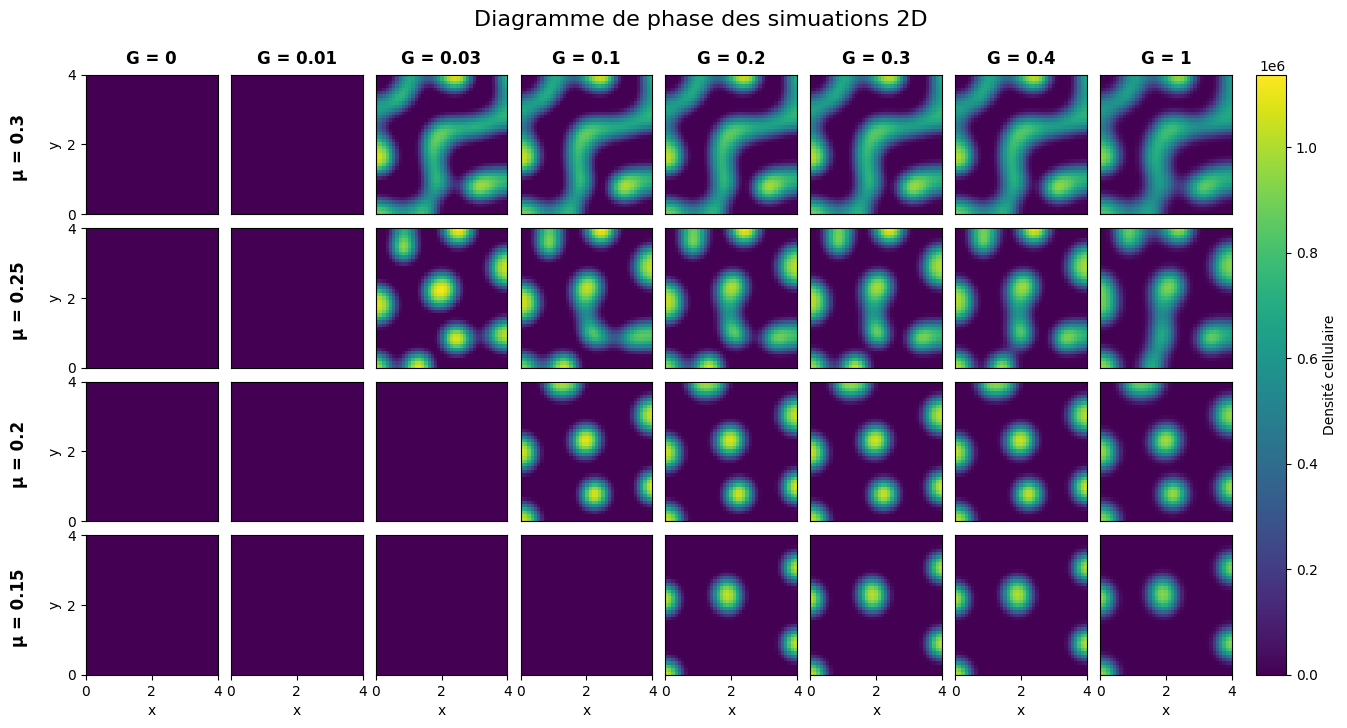

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Valeurs uniques des conditions
mus = np.sort(
    np.unique([
        r["mu"]
        for r in results
        if not np.isnan(r["mu"])
    ])
)

Gs = np.sort(
    np.unique([
        r["G"]
        for r in results
        if not np.isnan(r["G"])
    ])
)


n_mu = len(mus)
n_G = len(Gs)


# Taille d'un panneau
panel_size = 1.5

# Marges supplémentaires pour les labels et la colorbar
left_margin = 1.0
right_margin = 1.0
bottom_margin = 0.8
top_margin = 0.8
colorbar_width = 0.3

# Taille totale de la figure
fig_width = (
    n_G * panel_size
    + left_margin
    + right_margin
    + colorbar_width
)

fig_height = (
    n_mu * panel_size
    + bottom_margin
    + top_margin
)


fig = plt.figure(
    figsize=(fig_width, fig_height)
)

gs = fig.add_gridspec(
    n_mu,
    n_G,
    left=left_margin / fig_width,
    right=(left_margin + n_G * panel_size) / fig_width,
    bottom=bottom_margin / fig_height,
    top=(bottom_margin + n_mu * panel_size) / fig_height,
    wspace=0.1,
    hspace=0.1
)

axes = np.empty((n_mu, n_G), dtype=object)

for i in range(n_mu):
    for j in range(n_G):
        axes[i, j] = fig.add_subplot(gs[i, j])

'''
fig, axes = plt.subplots(
    n_mu,
    n_G,
    figsize=(1.5 * n_G, 1.5 * n_mu),
    squeeze=False,
    
)

# Supprime complètement les espaces entre les figures
fig.subplots_adjust(
    left=0.10,
    right=0.80,
    bottom=0.08,
    top=0.90,
    hspace=0,
    wspace=0.2
)
'''

# Même échelle de couleur pour toutes les images

all_profiles = np.concatenate([
    r["N"]
    for r in results
])

vmin = np.nanmin(all_profiles)
vmax = np.nanmax(all_profiles)

# Parcours des conditions
for i, mu in enumerate(mus):

    for j, G in enumerate(Gs):

        ax = axes[n_mu - i -1, j]

        
        # Chercher la simulation correspondant à mu et G
        simu = [
            r for r in results
            if np.isclose(r["mu"], mu)
            and np.isclose(r["G"], G)
        ]

        # Pas de simulation pour cette condition
        if len(simu) == 0:

            ax.axis("off")
            continue

        
        # Si plusieurs simulations existent,
        # on prend la première
        
        res = simu[0]

        N= res["N"]
        X = res["X"]
        Y = res["Y"]


        
        im = ax.imshow(
            N,
            origin="lower",
            aspect="auto",
            extent=[
                X.min(),
                X.max(),
                Y.min(),
                Y.max(),
            ],
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )
        # Force la case à être carrée
        #ax.set_box_aspect(1)
       

        ax.set_xticks([0, 2, 4])
        ax.set_yticks([0, 2, 4])

        
        # AXE X
        # Seulement sur la dernière ligne
        if i == 0:

            ax.set_xlabel("x")

            # On garde les ticks
            ax.tick_params(
                axis="x",
                which="both",
                bottom=True,
                labelbottom=True
            )

        else:

            # Supprime les traits ET les labels
            ax.tick_params(
                axis="x",
                which="both",
                bottom=False,
                top=False,
                labelbottom=False
            )

        
        # AXE Y
        # Seulement sur la colonne de gauche
        if j == 0:

            # Légende de l'axe
            ax.set_ylabel("y")

            # On garde les ticks et les valeurs
            ax.tick_params(
                axis="y",
                which="both",
                left=True,
                labelleft=True
            )

            
            # Condition μ à gauche de chaque ligne
            ax.text(
                -0.35,
                0.5,
                f"μ = {mu:g} \n \n ",
                transform=ax.transAxes,
                rotation=90,
                va="center",
                ha="center",
                fontsize=12,
                fontweight="bold"
            )

        else:

            # Supprime les traits ET les labels
            ax.tick_params(
                axis="y",
                which="both",
                left=False,
                right=False,
                labelleft=False
            )

        
        # Supprimer le contour noir
        #for spine in ax.spines.values():
            #spine.set_visible(False)

        
        # G au-dessus des colonnes
        

        if i == n_mu - 1:

            ax.set_title(
                f"G = {G:g}",
                fontsize=12,
                fontweight="bold",
                pad=8
            )


# Colorbar commune
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    fraction=0.025,
    pad=0.02
)

cbar.set_label(
    "Densité cellulaire"
)


fig.suptitle(
    "Diagramme de phase des simuations 2D",
    fontsize=16
)


outfile = folder / "diagramme_conditions_1D.png"

plt.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# Comparaison de plusieurs simulation

Cette cellule permet de regrouper dans un subplot plusieurs simulations sous la même échelle.

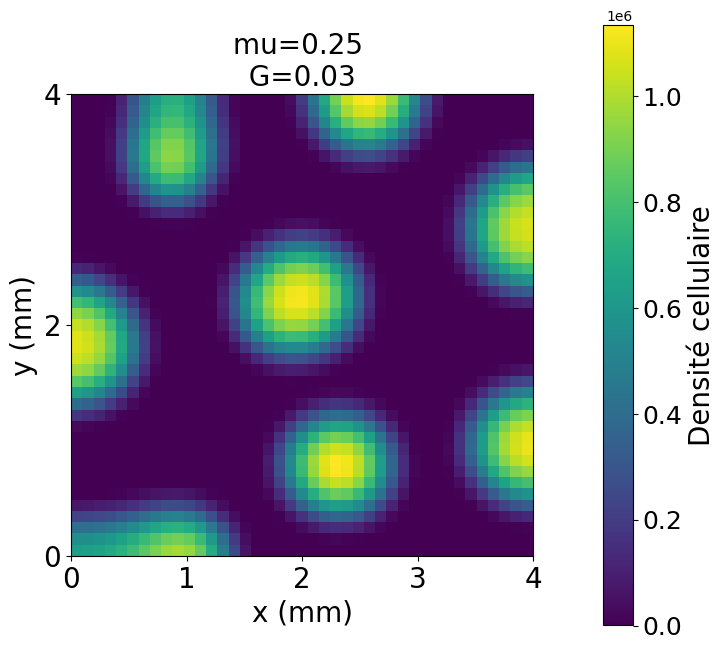

In [ ]:
from collections import defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


groups = defaultdict(list)

for res in results:
    key = (
        res["mu"],
        res["G"],
        res["cell"],
        res["t"],
    )
    groups[key].append(res)


# Conditions à comparer


conditions = [
    (0.25, 0.025, 25000, 300000)
    #(0.2, 0.1),
    #(0.4, 0.1)
]



fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(18*len(conditions),6),
    sharex=True,
    sharey=True
)
'''
all_profiles = np.concatenate([
    r["N"]
    for r in results
])

vmin = np.nanmin(all_profiles)
vmax = np.nanmax(all_profiles)'''

# Cas où une seule condition est demandée
if len(conditions) == 1:
    axes = [axes]

for ax, key in zip(axes, conditions):

    if key not in groups:
        ax.set_title("Condition absente")
        ax.axis("off")
        continue



    simu = sorted(
        groups[key]
    )

    
    N = simu[0]["N"]
    X = simu[0]["X"]
    Y = simu[0]["Y"]

    im = ax.imshow(
                N,
                origin="lower",
                aspect="equal",
                extent=[
                    X.min(),
                    X.max(),
                    Y.min(),
                    Y.max(),
                ],
                cmap="viridis",
                #vmin=vmin,
                #vmax=vmax
            )

  
    ax.set_title(
                f"mu={simu[0]["mu"]:.2f} \n G={simu[0]["G"]:.2f} " , fontsize = 20
            )
    ax.set_xlabel("x (mm)", fontsize = 20)
    
    ax.tick_params(axis='both', labelsize=20)
    

axes[0].set_ylabel("y (mm)", fontsize = 20)
axes[0].set_yticks([0, 2, 4])

# Une seule colorbar pour toute la figure
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=1.3
    
)
cbar.set_label("Densité cellulaire" , fontsize = 20)
cbar.ax.tick_params(
                labelsize=18
            )

#plt.tight_layout()

plt.savefig(
    folder / "Comparaison_spacetime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from collections import defaultdict
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


groups = defaultdict(list)

for res in results:
    key = (
        res["mu"],
        res["G"],
        res["cell"],
        res["t"],
    )
    groups[key].append(res)


# Conditions à comparer


conditions = [
    (0.25, 0.03, 50000, 2500),
    (0.25, 0.03, 50000, 10000),
    (0.25, 0.03, 50000, 25000)
    #(0.2, 0.1),
    #(0.4, 0.1)
]



fig, axes = plt.subplots(
    1,
    len(conditions),
    figsize=(6*len(conditions),6),
    sharex=True,
    sharey=True
)

all_profiles = np.concatenate([
    r["N"]
    for r in results
])

vmin = np.nanmin(all_profiles)
vmax = np.nanmax(all_profiles)

# Cas où une seule condition est demandée
if len(conditions) == 1:
    axes = [axes]

for ax, key in zip(axes, conditions):

    if key not in groups:
        ax.set_title("Condition absente")
        ax.axis("off")
        continue



    simu = sorted(
        groups[key]
    )

    
    N = simu[0]["N"]
    X = simu[0]["X"]
    Y = simu[0]["Y"]

    im = ax.imshow(
                N,
                origin="lower",
                aspect="equal",
                extent=[
                    X.min(),
                    X.max(),
                    Y.min(),
                    Y.max(),
                ],
                cmap="viridis",
                vmin=0,
                #vmax=vmax
            )

  
    '''ax.set_title(
                f"mu={simu[0]["mu"]:.2f} \n G={simu[0]["G"]:.2f} " , fontsize = 18
            )'''
    ax.set_title(
                f"t={simu[0]["t"]} " , fontsize = 18
            )
    ax.set_xlabel("x (mm)", fontsize = 16)
    
    ax.tick_params(axis='both', labelsize=16)
    

axes[0].set_ylabel("y (mm)", fontsize = 16)
#axes[0].set_yticks([0, 0.1, 0.2])

# Une seule colorbar pour toute la figure
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=1.3, 
    
)
cbar.set_label("Densité cellulaire" , fontsize = 16)

#plt.tight_layout()

plt.savefig(
    folder / "Comparaison_spacetime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Étude de la variabilité liée à la disposition initiale

Afin d'étudier l'influence de la configuration initiale des cellules, 20 simulations indépendantes sont réalisées avec des répartitions cellulaires aléatoires.

Les résultats obtenus pour ces différentes simulations sont regroupés dans un fichier Excel. Chaque feuille du fichier correspond à une simulation indépendante.

Pour chaque condition de simulation identifiée comme appartenant au régime Pattern, les grandeurs d'espacement et de longueur de correlation sont extraites.
Les résultats des différentes simulations sont ensuite comparés afin de quantifier la variabilité induite par la disposition initiale des cellules.

Pour chaque condition de simulation, les valeurs obtenues dans les différentes réalisations sont représentées sous forme de nuage de points. Chaque point correspond à une simulation indépendante. La moyenne et l'écart-type des différentes réalisations sont calculés.

*Remarque* ces données ne sont pas vraiment exploitables car l'algorithme de recherche des premiers voisins et d'autocorrelation ne sont pas extremement fiables en 2D. 

In [41]:
pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


C:\Users\lisab\AppData\Local\Temp\ipykernel_1460\3107804830.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('viridis')


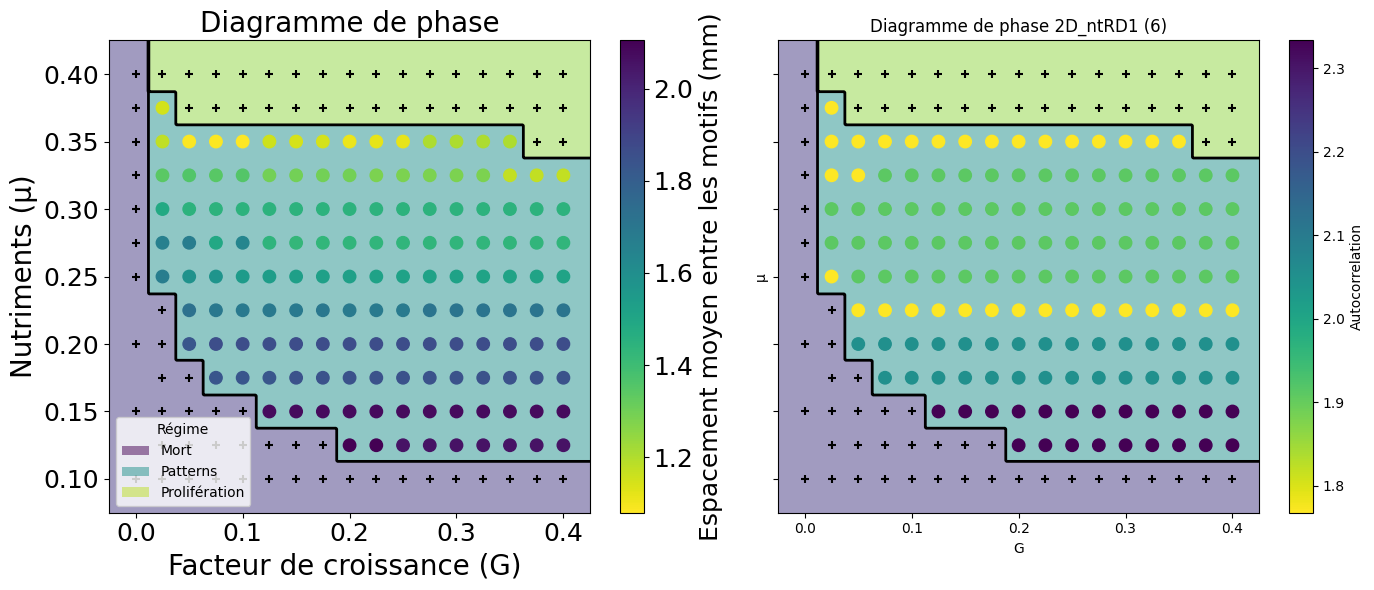

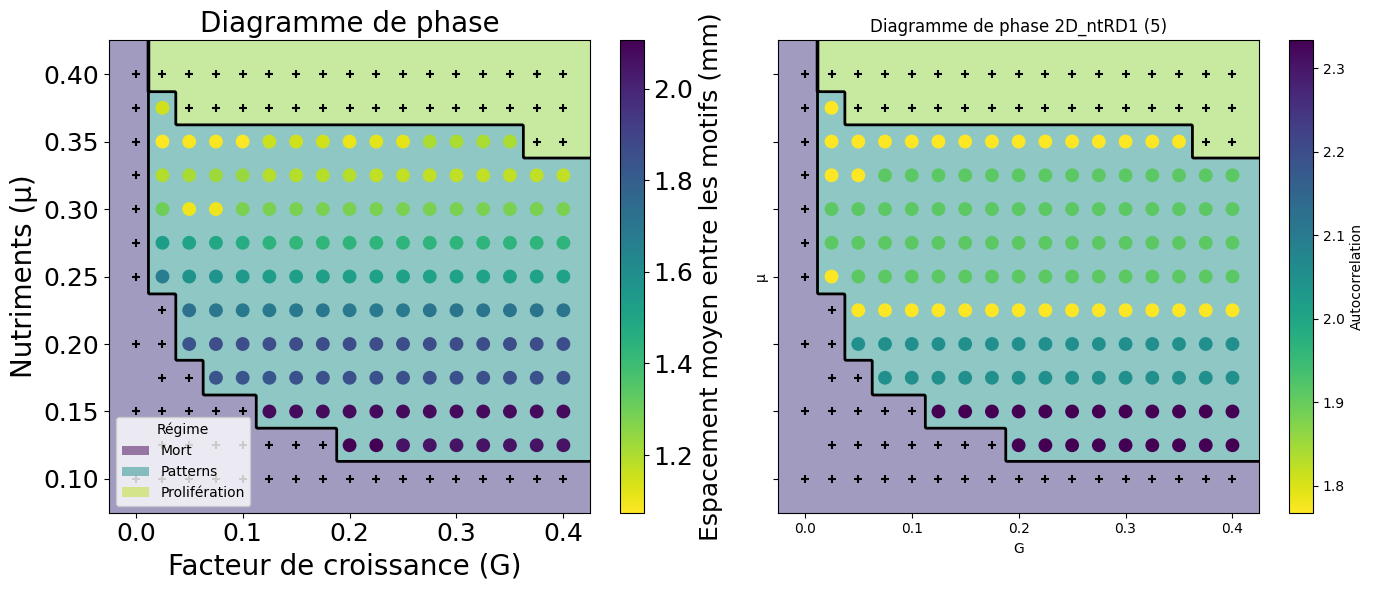

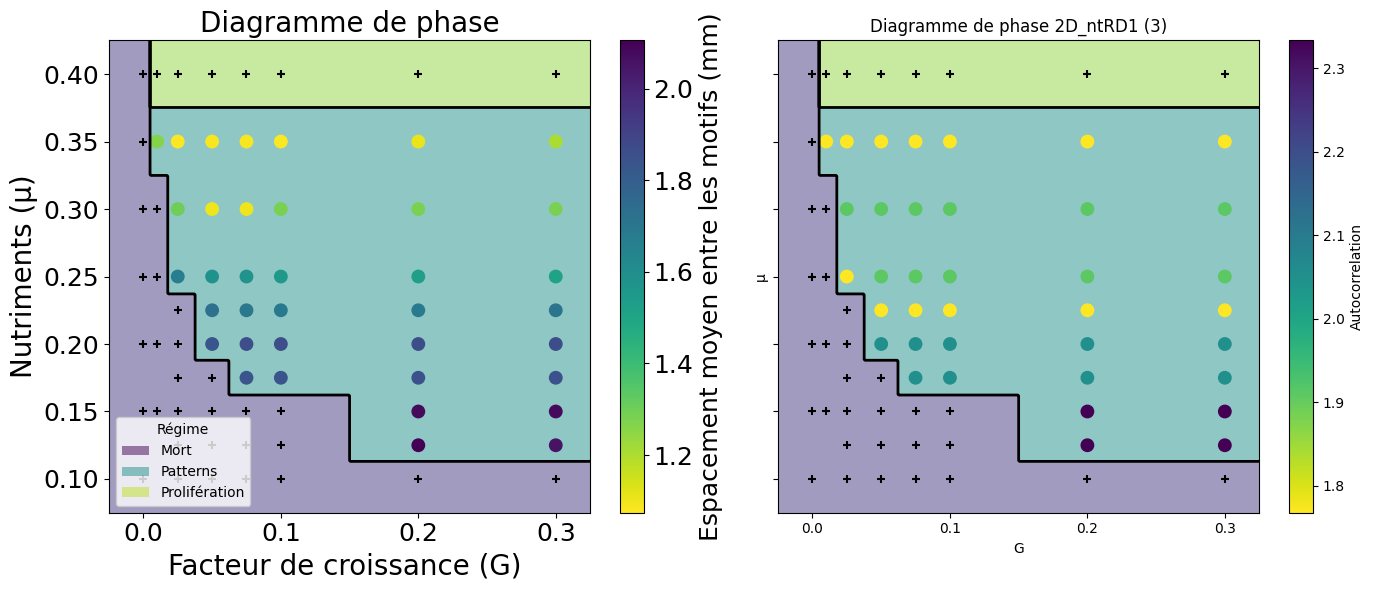

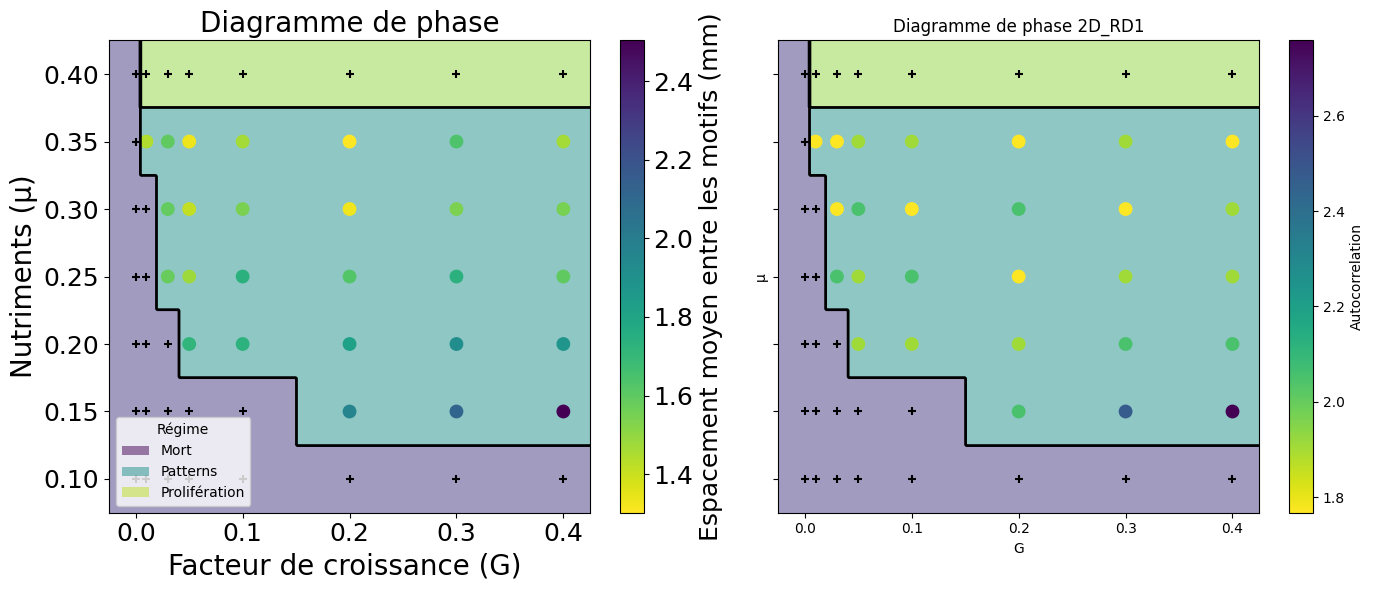

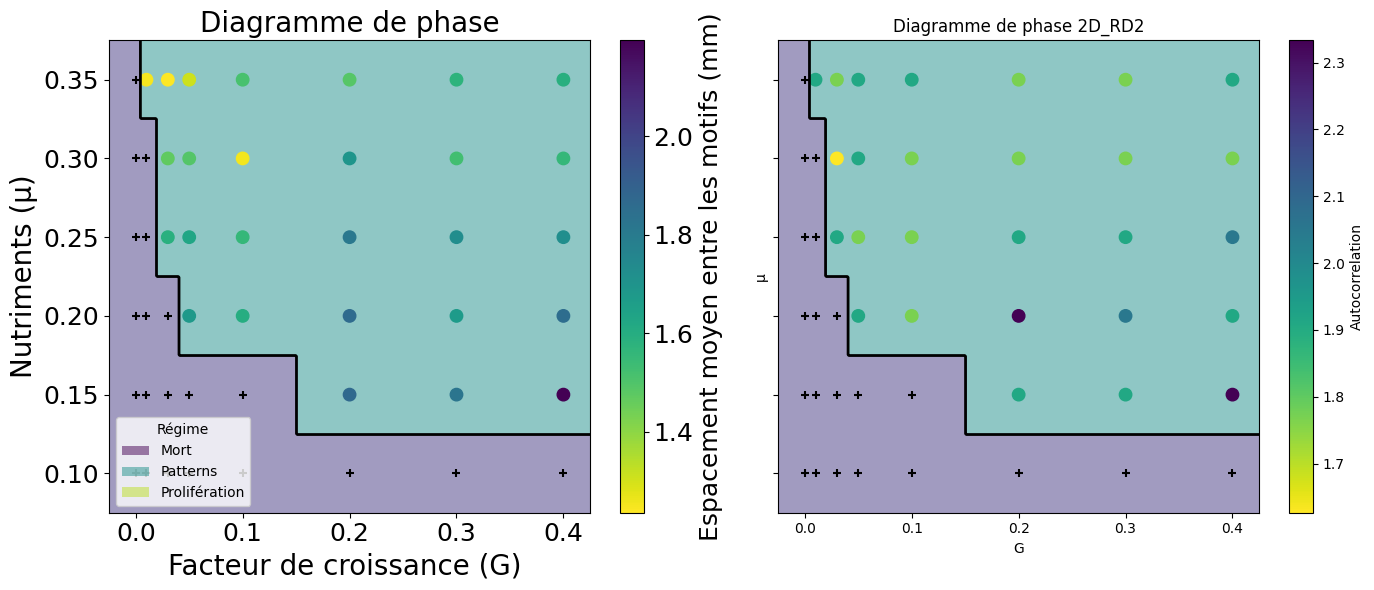

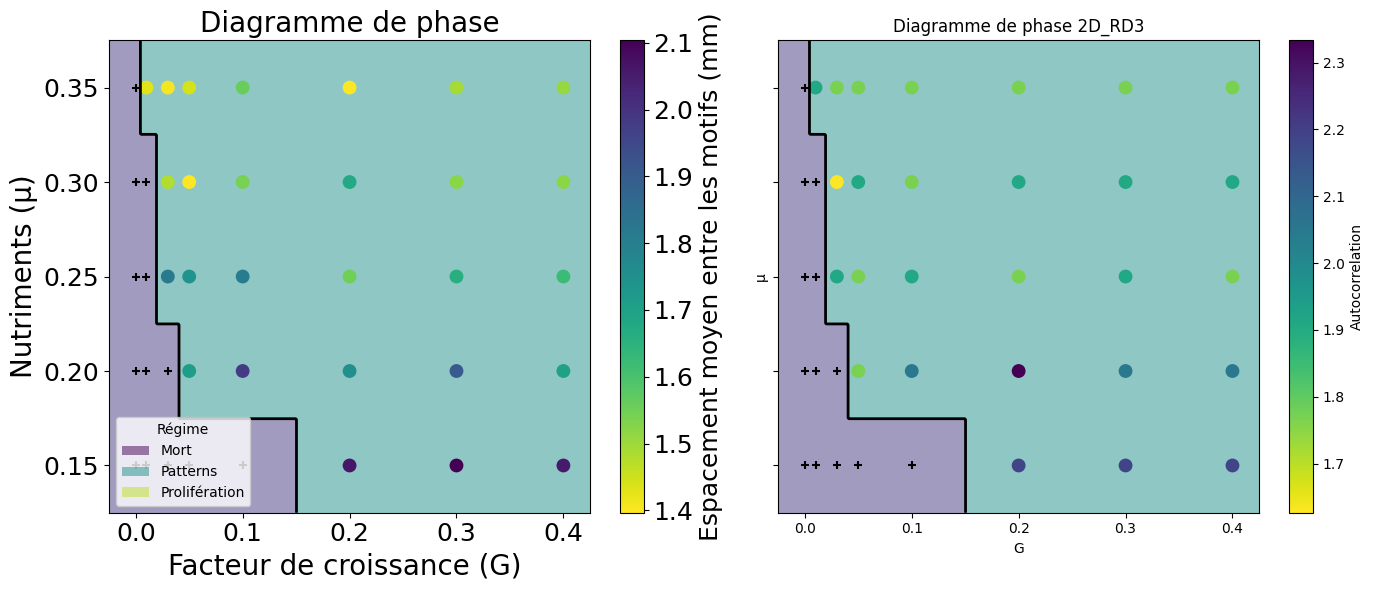

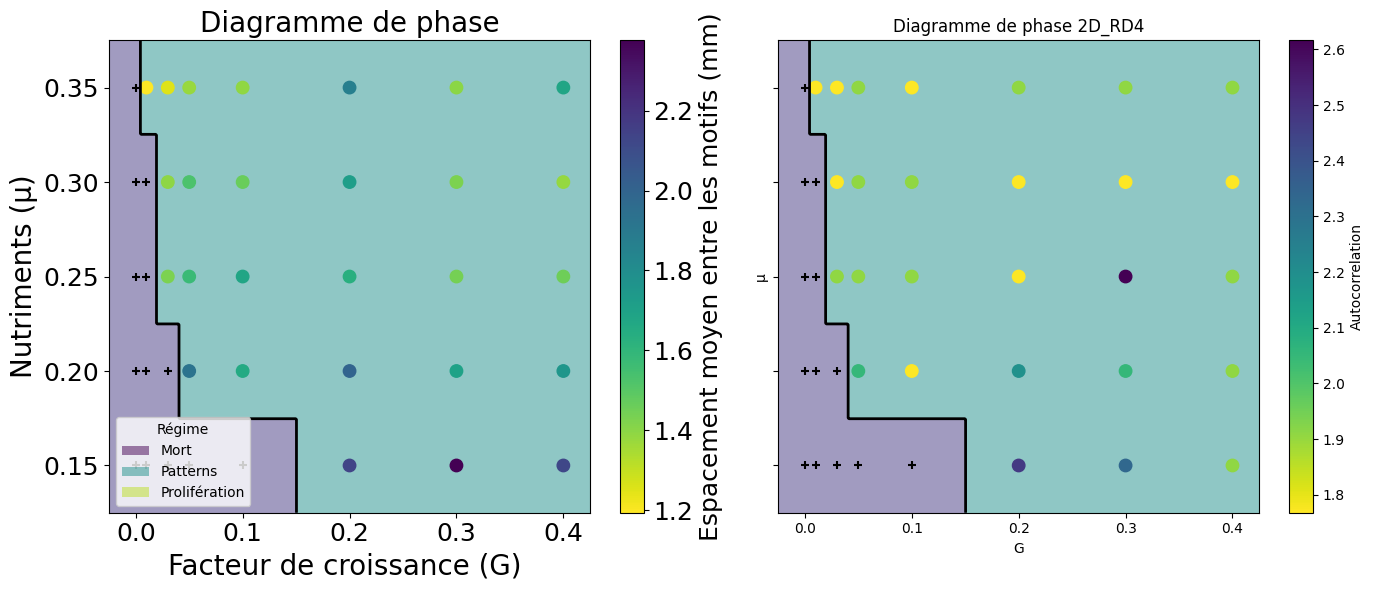

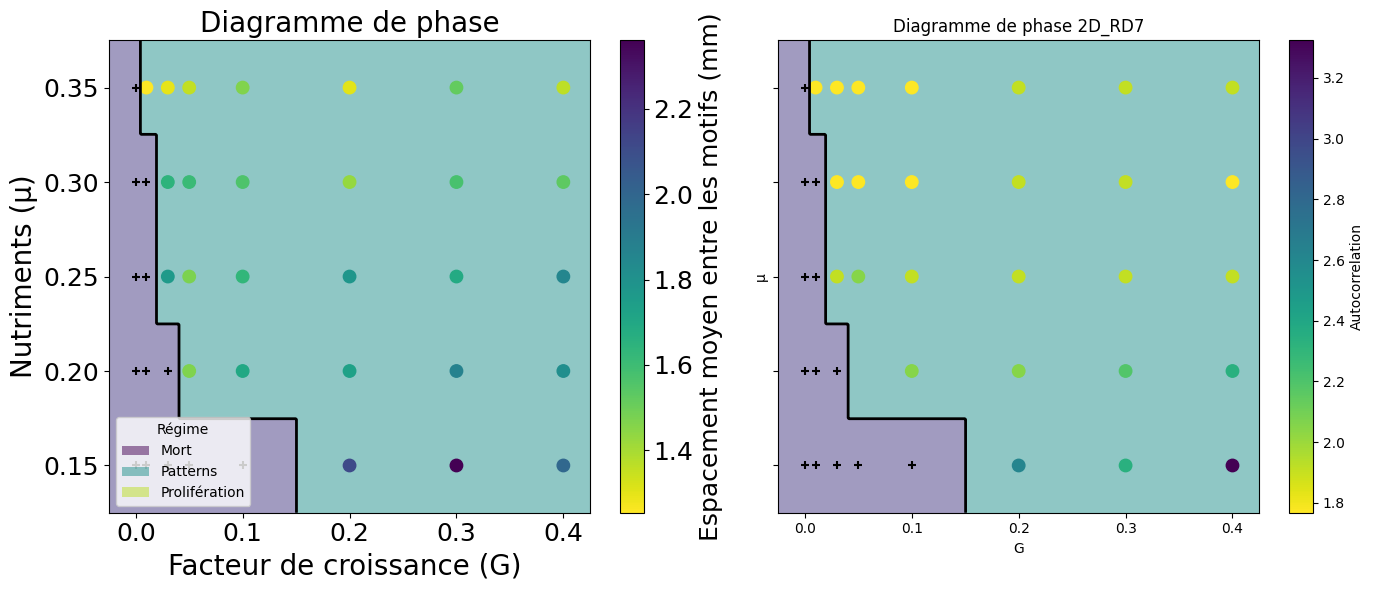

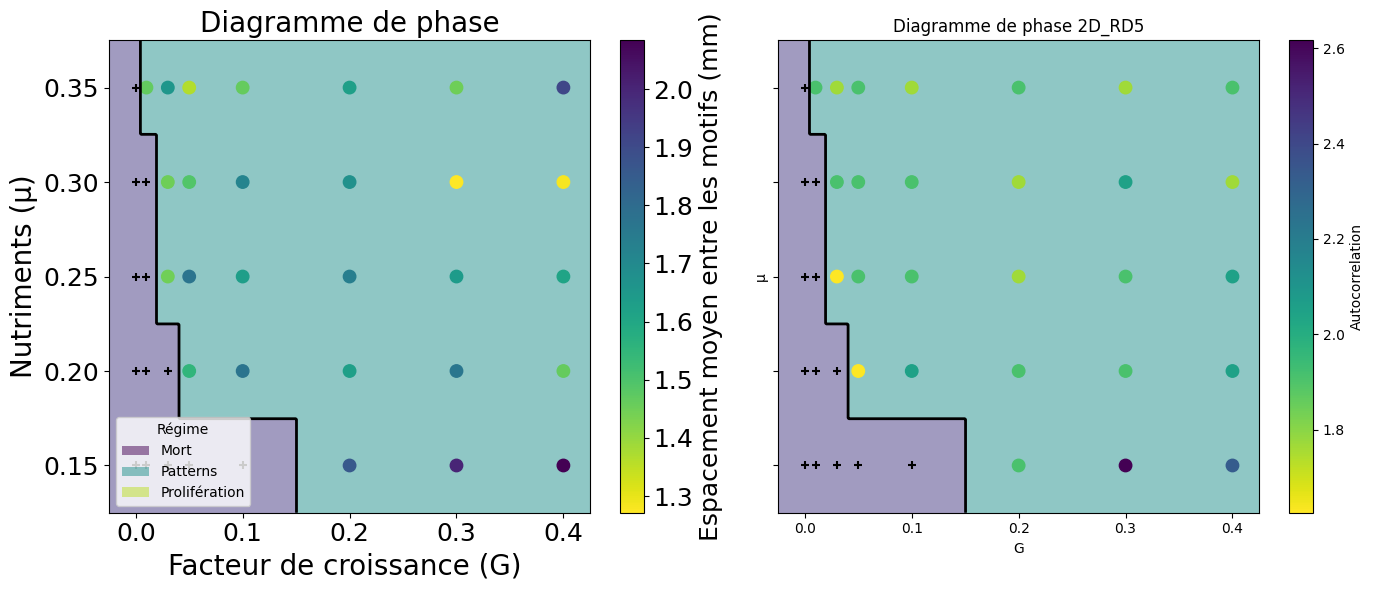

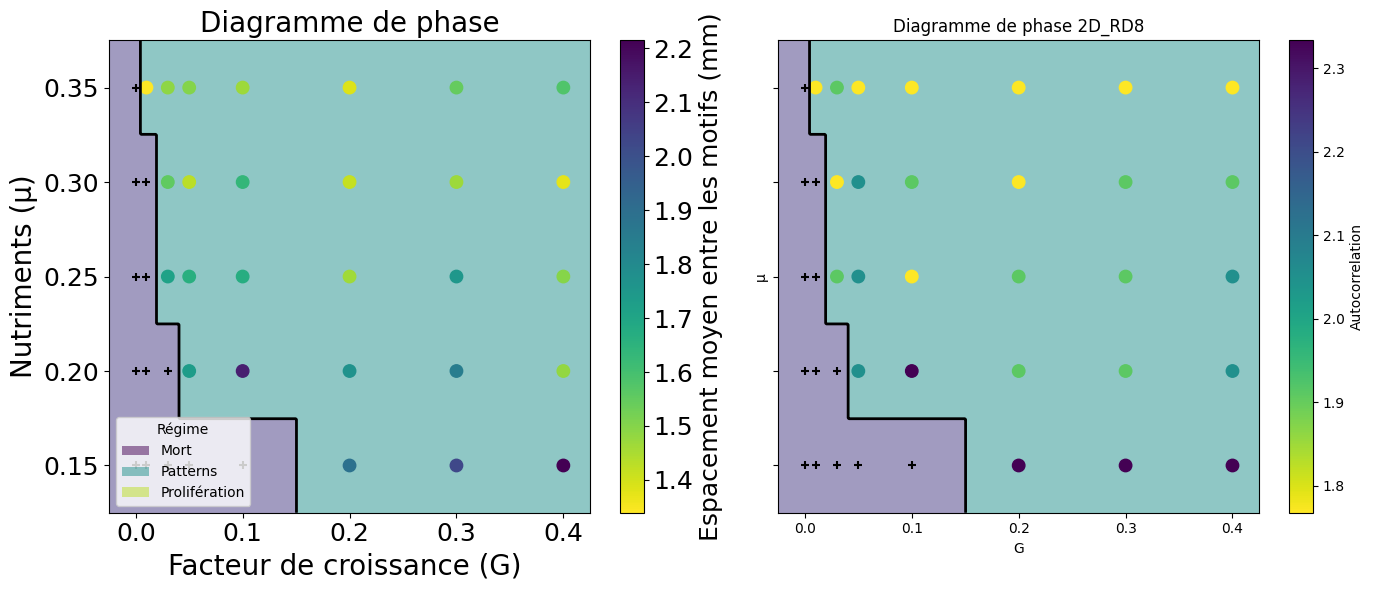

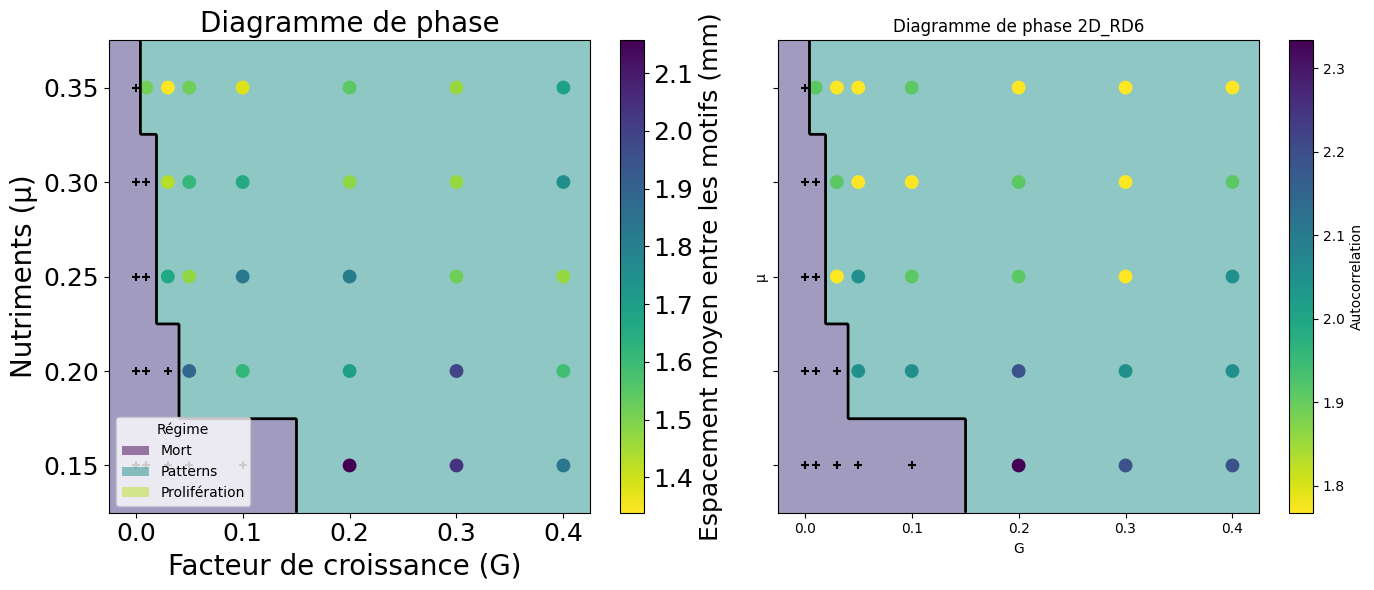

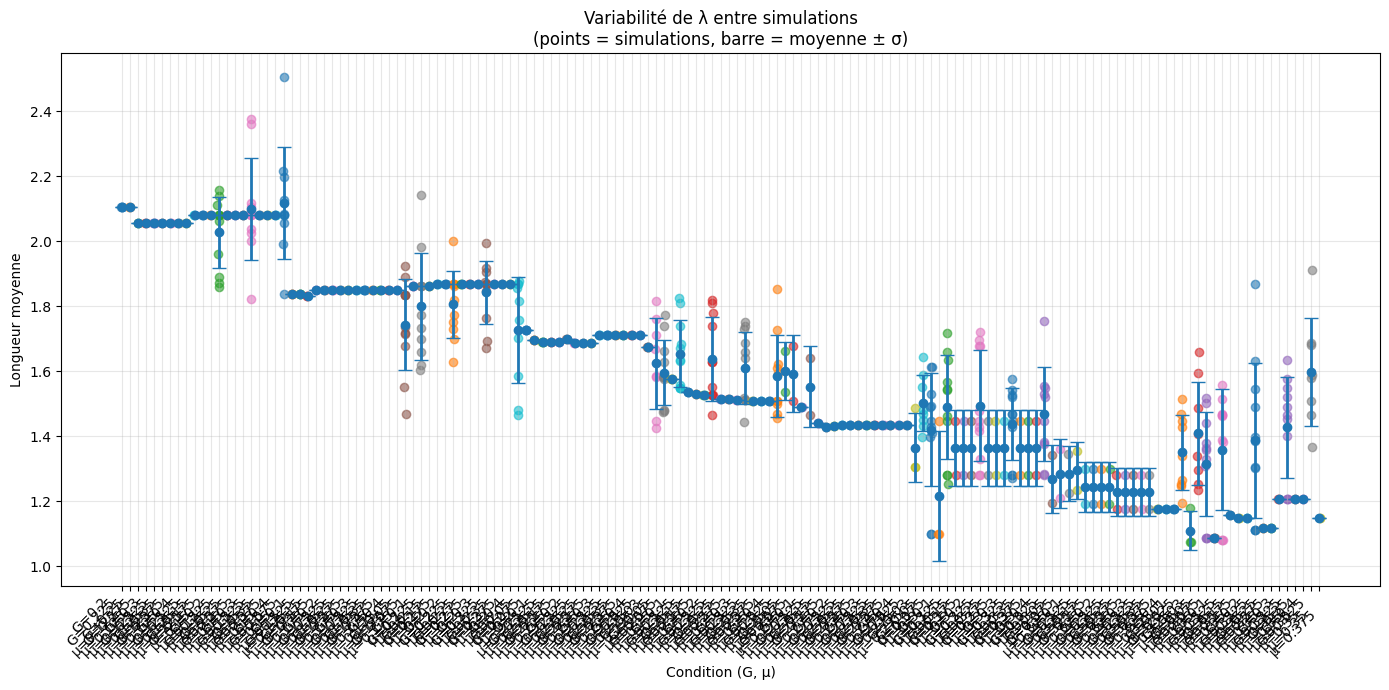

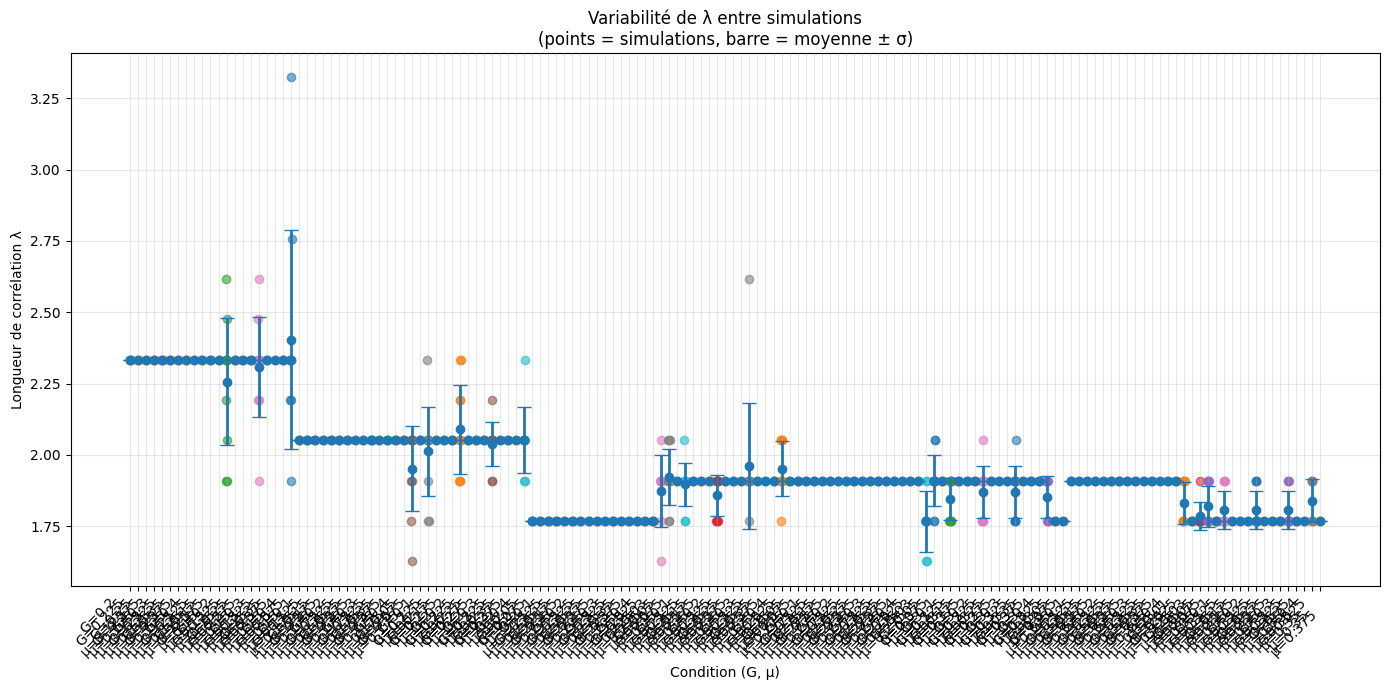

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.patches import Patch

excel_file = "./2D_ntRD1/Simu2D.xlsx"

sheets = pd.read_excel(
    excel_file,
    sheet_name=None
)


# Stockage des λ pour le graphe récapitulatif
all_pattern_data = []


# Une figure par feuille
for sheet_name, df in sheets.items():

        

    G = df["Column2"].values
    mu = df["Column1"].values
    lam2 = df["Column3"].values
    lam1 = df["Column4"].values
    cond = df["Column5"].values
    phase = np.zeros(len(df))

    phase[cond == "Mort"] = 0
    phase[cond == "Patterns"] = 1
    phase[cond == "Prolifération"] = 2

    mask_pattern = cond == "Patterns"

    for g_val, mu_val, lambda_val1, lambda_val2 in zip(
        G[mask_pattern],
        mu[mask_pattern],
        lam1[mask_pattern],
        lam2[mask_pattern]
    ):
        all_pattern_data.append({
            "Sheet": sheet_name,
            "G": g_val,
            "mu": mu_val,
            "lambda1": lambda_val1,
            "lambda2" : lambda_val2
        })

    gx = np.linspace(G.min()- 0.025, G.max() +0.025, 300)
    gy = np.linspace(mu.min() -0.025, mu.max() + 0.025, 300)

    GX, MU = np.meshgrid(gx, gy)

    orig_map=plt.cm.get_cmap('viridis')
    # reversing the original colormap using reversed() function
    Cmap = orig_map.reversed()


    phase_grid = griddata(
        (G, mu),
        phase,
        (GX, MU),
        method="nearest"
    )

    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(14,6),
        sharex=True,
        sharey=True
    )
   

    ax1.contourf(
        GX,
        MU,
        phase_grid,
        levels=[-0.5, 0.5, 1.5, 2.5],
        alpha=0.5
    )


    ax1.contour(
        GX,
        MU,
        phase_grid,
        levels=[0.5,1.5],
        colors='k',
        linewidths=2
    )

    mask_pattern = cond == "Patterns"

    sc1 = ax1.scatter(
        G[mask_pattern],
        mu[mask_pattern],
        c=lam1[mask_pattern],
        s=80,
        cmap = Cmap,        #edgecolors='k'
    )
    cbar = fig.colorbar(
        sc1,
        ax=ax1,
        label="Espacement moyen entre les motifs (mm)"
    )
    cbar.set_label("Espacement moyen entre les motifs (mm)", fontsize =18)
    cbar.ax.tick_params(
                            labelsize=18
                        )
    

    mask_mort = cond == "Mort" 
    ax1.scatter(
        G[mask_mort],
        mu[mask_mort],
        c='k',
        marker='+',
        s=30
    )

    mask_Prolif = cond == "Prolifération" 
    ax1.scatter(
        G[mask_Prolif],
        mu[mask_Prolif],
        c='k',
        marker='+',
        s=30
    )
    cmap = plt.cm.viridis
    norm = plt.Normalize(vmin=0, vmax=2)

    legend_elements = [
        Patch(
            facecolor=cmap(norm(0)), alpha=0.5,
            label="Mort"
        ),
        Patch(
            facecolor=cmap(norm(1)), alpha=0.5,
            label="Patterns"
        ),
        Patch(
            facecolor=cmap(norm(1.8)), alpha=0.5,
            label="Prolifération"
        )
    ]

    ax1.legend(
    handles=legend_elements,
    title="Régime",
    loc="lower left"
)
    ax1.set_xlabel("Facteur de croissance (G) ", fontsize = 20)
    ax1.set_ylabel("Nutriments (μ)", fontsize = 20) 
    ax1.set_title("Diagramme de phase", fontsize = 20)
    ax1.tick_params(
            axis="both",
            labelsize=18
        )
    

    #ax1.set_title("Diagramme de phase longeur moyenne")

    ax2.contourf(
        GX,
        MU,
        phase_grid,
        levels=[-0.5,0.5,1.5,2.5],
        alpha=0.5
    )
    ax2.contour(
        GX,
        MU,
        phase_grid,
        levels=[0.5,1.5],
        colors='k',
        linewidths=2
    )

    mask_pattern = cond == "Patterns"

    sc = ax2.scatter(
        G[mask_pattern],
        mu[mask_pattern],
        c=lam2[mask_pattern],
        s=80,
        cmap = Cmap,
        #edgecolors='k'
    )

    fig.colorbar(
        sc,
        ax=ax2,
        label="Autocorrelation"
    )
    

    mask_mort = cond == "Mort" 
    ax2.scatter(
        G[mask_mort],
        mu[mask_mort],
        c='k',
        marker='+',
        s=30
    )

    mask_Prolif = cond == "Prolifération" 
    ax2.scatter(
        G[mask_Prolif],
        mu[mask_Prolif],
        c='k',
        marker='+',
        s=30
    )

    ax2.set_xlabel("G")
    ax2.set_ylabel("μ")

    #ax2.set_title("Diagramme de phase autocorrelation")

    plt.tight_layout()
    plt.title(
        f"Diagramme de phase {sheet_name}"
    )



plt.show()



# Graphe de dispersion des λ entre simulations
stats_df = pd.DataFrame(all_pattern_data)

if len(stats_df) > 0:

    summary1 = (
        stats_df
        .groupby(["mu" ,"G"])
        .agg(
            lambda_mean1=("lambda1", "mean"),
            lambda_std1=("lambda1", "std"),
            n=("lambda1", "count")
        )
        .reset_index()
    )
    summary1 = summary1[summary1["n"] > 1].reset_index(drop=True)

    plt.figure(figsize=(14,7))

    # Points individuels (une valeur par feuille)
    for i, row in summary1.iterrows():

        subset = stats_df[
            (stats_df["G"] == row["G"])
            &
            (stats_df["mu"] == row["mu"])
        ]

        xvals = np.random.normal(
            loc=i,
            scale=0.05,
            size=len(subset)
        )

        plt.scatter(
            xvals,
            subset["lambda1"],
            alpha=0.6
        )

    
    # Moyenne ± écart-type
    plt.errorbar(
        np.arange(len(summary1)),
        summary1["lambda_mean1"],
        yerr=summary1["lambda_std1"],
        fmt='o',
        capsize=5,
        linewidth=2
    )

    labels = [
        f"G={g:.3g}\nμ={m:.3g}"
        for g, m in zip(
            summary1["G"],
            summary1["mu"]
        )
    ]

    plt.xticks(
        np.arange(len(summary1)),
        labels,
        rotation=45,
        ha="right",
        
    )

    plt.ylabel("Longueur moyenne")
    plt.xlabel("Condition (G, μ)")
    plt.title(
        "Variabilité de λ entre simulations\n"
        "(points = simulations, barre = moyenne ± σ)"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14,7))

    
    # Points individuels (une valeur par feuille)
    summary2 = (
        stats_df
        .groupby([ "mu","G"])
        .agg(
            lambda_mean2=("lambda2", "mean"),
            lambda_std2=("lambda2", "std"),
            n=("lambda2", "count")
        )
        .reset_index()
    )
    summary2 = summary2[summary2["n"] > 1].reset_index(drop=True)

    for i, row in summary2.iterrows():

        subset = stats_df[
            (stats_df["mu"] == row["mu"])
            &
            (stats_df["G"] == row["G"])
        ]

        xvals = np.random.normal(
            loc=i,
            scale=0.05,
            size=len(subset)
        )

        plt.scatter(
            xvals,
            subset["lambda2"],
            alpha=0.6
        )

    
    # Moyenne ± écart-type
    plt.errorbar(
        np.arange(len(summary2)),
        summary2["lambda_mean2"],
        yerr=summary2["lambda_std2"],
        fmt='o',
        capsize=5,
        linewidth=2
    )

    labels = [
        f"G={g:.3g}\nμ={m:.3g}"
        for g, m in zip(
            summary2["G"],
            summary2["mu"]
            
        )
    ]

    plt.xticks(
        np.arange(len(summary2)),
        labels,
        rotation=45,
        ha="right",
        
    )

    plt.ylabel("Longueur de corrélation λ")
    plt.xlabel("Condition (G, μ)")
    plt.title(
        "Variabilité de λ entre simulations\n"
        "(points = simulations, barre = moyenne ± σ)"
    )

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Un diagramme de phase moyen est ensuite construit à partir des 20 simulations indépendantes.

La classification des régimes est réalisée selon la règle suivante :

Une condition est classée dans le régime Pattern sur le diagramme de phase final uniquement si elle est identifiée comme Pattern dans l'ensemble des simulations indépendantes.

Cette convention permet de sélectionner les conditions présentant un comportement Pattern robuste vis-à-vis de la configuration initiale.

La taille des points représente la variabilité entre les simulations, mesurée à partir de l'écart-type.

Ainsi :

un petit point correspond à une faible variabilité ;
un gros point correspond à une forte variabilité entre les simulations.

Cette représentation permet donc de visualiser simultanément le comportement moyen du système et sa sensibilité aux conditions initiales.

C:\Users\lisab\AppData\Local\Temp\ipykernel_13488\3267315978.py:169: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_map=plt.cm.get_cmap('viridis')


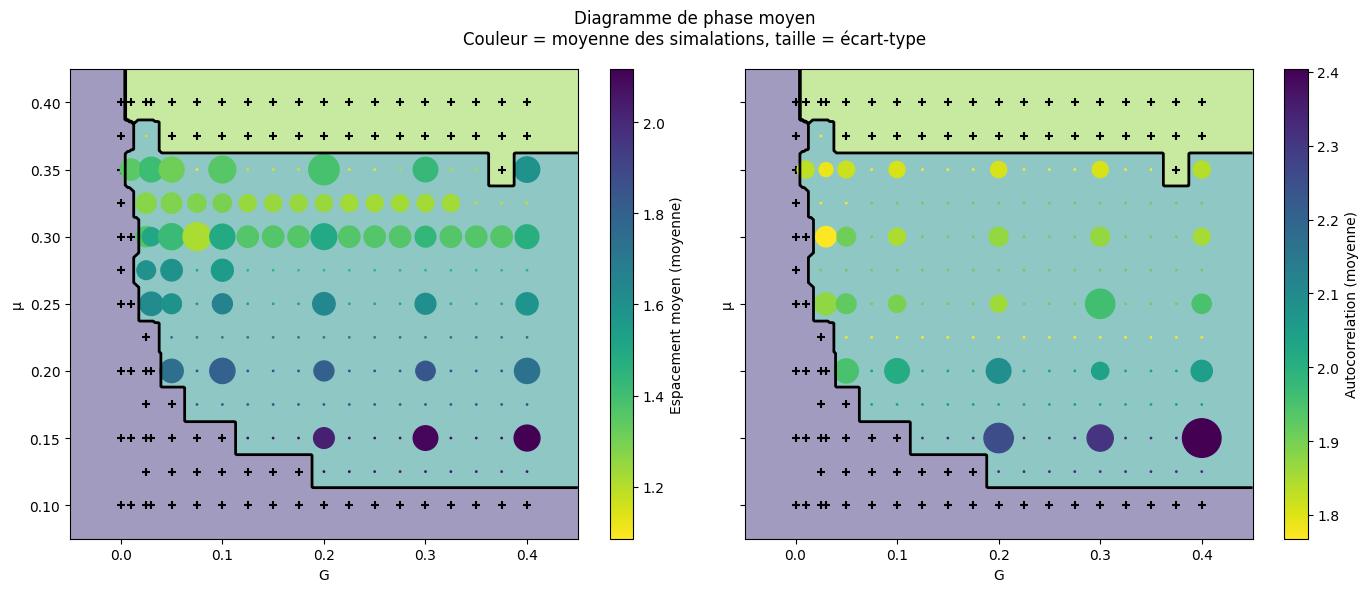

In [ ]:

all_data = []

for sheet_name, df in sheets.items():

    for _, row in df.iterrows():

        all_data.append({
            "G": row["Column2"],
            "mu": row["Column1"],
            "lambda1": row["Column4"],
            "lambda2": row["Column3"],
            "cond": row["Column5"]
        })

all_df = pd.DataFrame(all_data)

pattern_df = all_df[
    all_df["cond"] == "Patterns"
]

summary = (
    pattern_df
    .groupby(["G", "mu"])
    .agg(
        lambda1_mean=("lambda1", "mean"),
        lambda1_std=("lambda1", "std"),
        lambda2_mean=("lambda2", "mean"),
        lambda2_std=("lambda2", "std"),
        n=("lambda1", "count")
    )
    .reset_index()
)

# On ne conserve que les conditions ayant au moins 3 simulations en Pattern
summary = summary[summary["n"] > 1].reset_index(drop=True)

summary = summary.fillna(0)

phase_data = []

for (g, mu), sub in all_df.groupby(["G", "mu"]):

    conds = set(sub["cond"])

    if "Patterns" in conds:
        phase = 1
    elif "Prolifération" in conds:
        phase = 2
    else:
        phase = 0

    phase_data.append({
        "G": g,
        "mu": mu,
        "phase": phase
    })

phase_df = pd.DataFrame(phase_data)

gx = np.linspace(
    phase_df["G"].min()-0.05,
    phase_df["G"].max()+0.05,
    300
)

gy = np.linspace(
    phase_df["mu"].min()-0.025,
    phase_df["mu"].max()+0.025,
    300
)

GX, MU = np.meshgrid(gx, gy)

phase_grid = griddata(
    (phase_df["G"], phase_df["mu"]),
    phase_df["phase"],
    (GX, MU),
    method="nearest"
)


size_scale = 2000

sizes1 = 1 + size_scale * summary["lambda1_std"]
sizes2 = 1 + size_scale * summary["lambda2_std"]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14,6),
    sharex=True,
    sharey=True
)

for ax in [ax1, ax2]:

    ax.contourf(
        GX,
        MU,
        phase_grid,
        levels=[-0.5,0.5,1.5,2.5],
        alpha=0.5
    )

    ax.contour(
        GX,
        MU,
        phase_grid,
        levels=[0.5,1.5],
        colors="k",
        linewidths=2
    )


mort = phase_df["phase"] == 0
prolif = phase_df["phase"] == 2

for ax in [ax1, ax2]:

    ax.scatter(
        phase_df.loc[mort, "G"],
        phase_df.loc[mort, "mu"],
        marker="+",
        c="k",
        s=30
    )

    ax.scatter(
        phase_df.loc[prolif, "G"],
        phase_df.loc[prolif, "mu"],
        marker="+",
        c="k",
        s=30
    )


orig_map=plt.cm.get_cmap('viridis')

# reversing the original colormap using reversed() function
Cmap = orig_map.reversed()
sc1 = ax1.scatter(
    summary["G"],
    summary["mu"],
    c=summary["lambda1_mean"],
    s=sizes1,
    cmap=Cmap,
    #edgecolors="k"
)

fig.colorbar(
    sc1,
    ax=ax1,
    label="Espacement moyen (moyenne)"
)

ax1.set_xlabel("G")
ax1.set_ylabel("μ")

sc2 = ax2.scatter(
    summary["G"],
    summary["mu"],
    c=summary["lambda2_mean"],
    s=sizes2,
    cmap=Cmap,
    #edgecolors="k"
)

fig.colorbar(
    sc2,
    ax=ax2,
    label="Autocorrelation (moyenne)"
)

ax2.set_xlabel("G")
ax2.set_ylabel("μ")

plt.suptitle(
    "Diagramme de phase moyen\n"
    "Couleur = moyenne des simalations, taille = écart-type"
)

plt.tight_layout()
plt.show()

In [ ]:
dossier = "CorrTemps"

matfile = Traitement_2D(f"./{dossier}/mu_0.250_G_0.030_t_300000_cell_50000.mat")
data = scipy.io.loadmat(f"./{dossier}/mu_0.250_G_0.030_t_300000_cell_50000Time.mat")
import numpy as np
import matplotlib.pyplot as plt

t = np.asarray(data["time"]).squeeze()
va = np.asarray(data["va"]).squeeze()

N = np.asarray(matfile["N"])
X = np.asarray(matfile["X"]).squeeze()
Y = np.asarray(matfile["Y"]).squeeze()

print("t shape :", t.shape)
print("va shape:", va.shape)
print("N shape :", N.shape)
print("X shape :", X.shape)
print("Y shape :", Y.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --------------------------------------------------
# Image 2D
# --------------------------------------------------

im = axes[0].imshow(
    N,
    origin="lower",
    aspect="equal",   # IMPORTANT : carré
    extent=[
        X.min(), X.max(),
        Y.min(), Y.max()
    ],
    cmap="viridis"
)

axes[0].set_xlabel("x (mm)", fontsize=16)
axes[0].set_ylabel("y (mm)", fontsize=16)
axes[0].tick_params(axis="both", labelsize=16)

cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Densité cellulaire", fontsize=16)

# --------------------------------------------------
# Quantité totale de cellules
# --------------------------------------------------

N_total = np.sum(N)

axes[1].plot(t[1:25000], va[1:25000]
)

axes[1].set_xlabel("Temps", fontsize=16)
axes[1].set_ylabel("Nombre total de cellules", fontsize=16)
axes[1].tick_params(axis="both", labelsize=16)
axes[1].grid(True)

plt.tight_layout()
plt.show()




In [ ]:
dossier = "CorrTemps"

matfile = Traitement_2D(f"./{dossier}/mu_0.250_G_0.030_t_300000_cell_25000.mat")
data = scipy.io.loadmat(f"./{dossier}/mu_0.250_G_0.030_t_300000_cell_25000Time.mat")

import numpy as np
import matplotlib.pyplot as plt

t = np.asarray(data["time"]).squeeze()
va = np.asarray(data["va"]).squeeze()

N = np.asarray(matfile["N"])
X = np.asarray(matfile["X"]).squeeze()
Y = np.asarray(matfile["Y"]).squeeze()

print("t shape :", t.shape)
print("va shape:", va.shape)
print("N shape :", N.shape)
print("X shape :", X.shape)
print("Y shape :", Y.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --------------------------------------------------
# Image 2D
# --------------------------------------------------

im = axes[0].imshow(
    N,
    origin="lower",
    aspect="equal",   # IMPORTANT : carré
    extent=[
        X.min(), X.max(),
        Y.min(), Y.max()
    ],
    cmap="viridis"
)

axes[0].set_xlabel("x (mm)", fontsize=16)
axes[0].set_ylabel("y (mm)", fontsize=16)
axes[0].tick_params(axis="both", labelsize=16)

cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label("Densité cellulaire", fontsize=16)

# --------------------------------------------------
# Quantité totale de cellules
# --------------------------------------------------

N_total = np.sum(N)

axes[1].plot(t[1:25000], va[1:25000]
)

axes[1].set_xlabel("Temps", fontsize=16)
axes[1].set_ylabel("Nombre total de cellules", fontsize=16)
axes[1].tick_params(axis="both", labelsize=16)
axes[1].grid(True)

plt.tight_layout()
plt.show()